In [14]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [ ]:
#Step 2: Load Dataset
df = pd.read_csv("Zomato_with_city_cuisine.csv")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)        city    cuisine  
0                          800          Buffet       Delhi    Chinese  
1                          800          Buffet   Bangalore  Fast Food  
2                          800          Buffet        Pune    Chinese  
3                          300          Buffet  Chandigarh       Cafe  
4                          600          Buffet  Chandigarh       Cafe  


In [17]:
#Step 3: Check Column Names
print(df.columns.tolist())

['name', 'online_order', 'book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)', 'city', 'cuisine']


In [18]:
#Step 4: Dataset Understanding
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(148, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
 7   city                         148 non-null    str  
 8   cuisine                      148 non-null    str  
dtypes: int64(2), str(7)
memory usage: 10.5 KB
None

Missing Values:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_c

In [19]:
#Step 5: Data Cleaning
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df.rename(columns={
    'rate':'Rating',
    'votes':'Votes',
    'approx_cost(for two people)':'Cost',
    'city':'City',
    'cuisine':'Cuisine'
}, inplace=True)
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

print(df[['Rating']].head())

   Rating
0     4.1
1     4.1
2     3.8
3     3.7
4     3.8


In [20]:
#Step 6: Verify Cleaning
print(df.dtypes)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

name                   str
online_order           str
book_table             str
Rating             float64
Votes                int64
Cost                 int64
listed_in(type)        str
City                   str
Cuisine                str
dtype: object

Missing Values After Cleaning:
name               0
online_order       0
book_table         0
Rating             0
Votes              0
Cost               0
listed_in(type)    0
City               0
Cuisine            0
dtype: int64


In [21]:
#Step 7: Descriptive Statistics
numerical_cols = ['Votes', 'Cost', 'Rating']

for col in numerical_cols:

    print("\n", "="*40)

    print("Column:", col)

    print("Mean:", df[col].mean())

    print("Median:", df[col].median())

    print("Mode:", df[col].mode()[0])

    print("Standard Deviation:", df[col].std())

    print("Variance:", df[col].var())


Column: Votes
Mean: 264.81081081081084
Median: 43.5
Mode: 0
Standard Deviation: 653.6769506420574
Variance: 427293.55580069864

Column: Cost
Mean: 418.2432432432432
Median: 400.0
Mode: 300
Standard Deviation: 223.085097750588
Variance: 49766.96083838941

Column: Rating
Mean: 3.6331081081081082
Median: 3.7
Mode: 3.8
Standard Deviation: 0.4022705140380333
Variance: 0.16182156646442358


City with Highest Restaurants:
Delhi
Count: 20
City
Delhi         20
Chandigarh    19
Pune          17
Jaipur        17
Chennai       15
Mumbai        13
Lucknow       13
Hyderabad     13
Bangalore     12
Kolkata        9
Name: count, dtype: int64


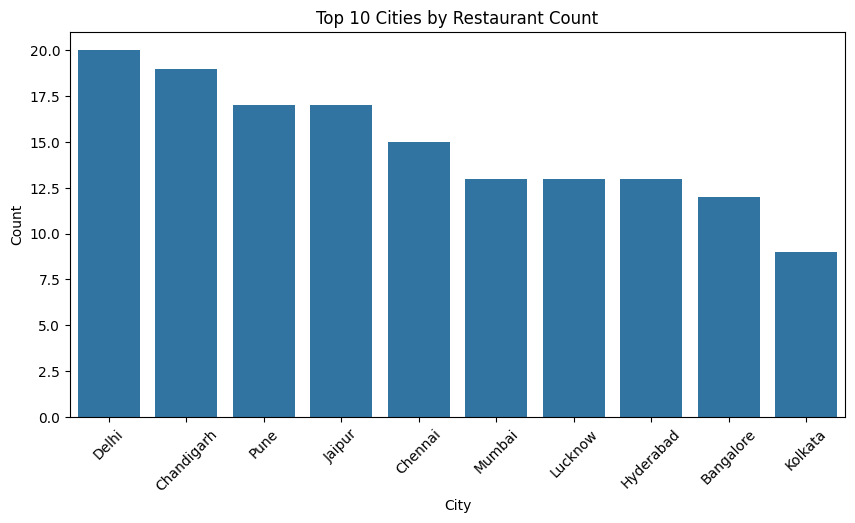

In [22]:
#Step 8: Restaurant Distribution Analysis
#Highest Restaurant City
city_count = df['City'].value_counts()

print("City with Highest Restaurants:")

print(city_count.idxmax())

print("Count:", city_count.max())
#Top 10 Cities
top10 = df['City'].value_counts().head(10)

print(top10)
#Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.title("Top 10 Cities by Restaurant Count")

plt.xlabel("City")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Cuisine
Italian         22
South Indian    19
Cafe            18
North Indian    18
Desserts        17
Biryani         14
Chinese         13
Street Food     10
Fast Food        9
Continental      8
Name: count, dtype: int64


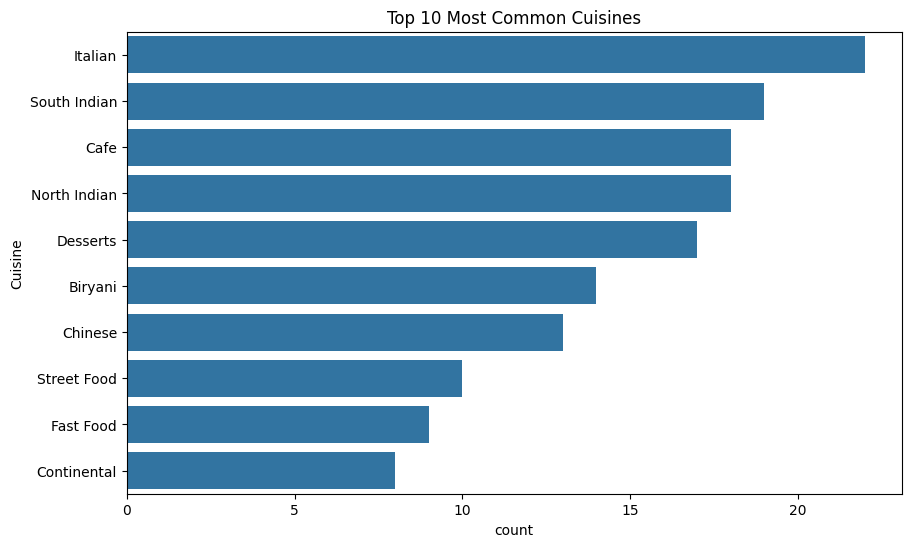

In [23]:
#Task 5: Cuisine Analysis
top_cuisines = df['Cuisine'].value_counts().head(10)

print(top_cuisines)
plt.figure(figsize=(10,6))

sns.countplot(
    y='Cuisine',
    data=df,
    order=df['Cuisine'].value_counts().index[:10]
)

plt.title("Top 10 Most Common Cuisines")

plt.show()

Cuisine
Fast Food       3.977778
Biryani         3.692857
South Indian    3.684211
North Indian    3.661111
Italian         3.631818
Cafe            3.588889
Desserts        3.570588
Street Food     3.560000
Chinese         3.553846
Continental     3.412500
Name: Rating, dtype: float64


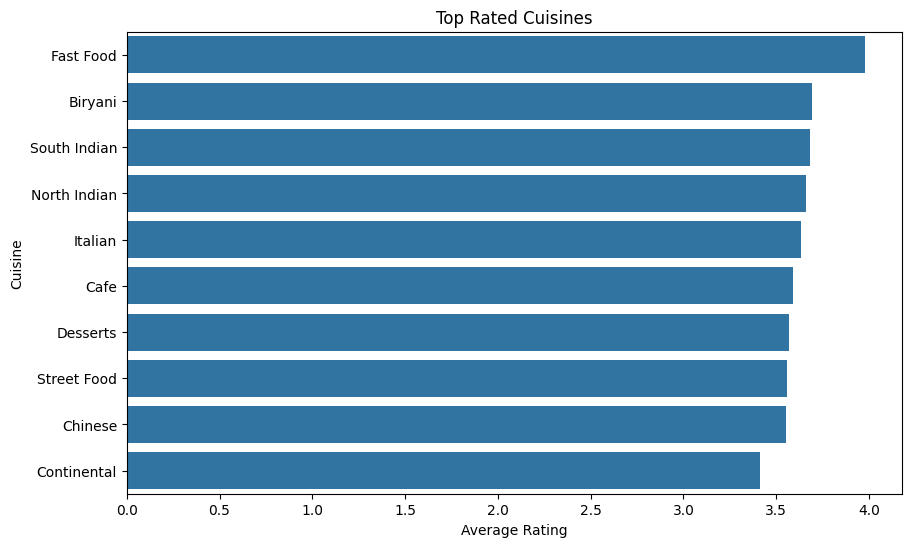

In [24]:
#Q2 Which Cuisines Have Highest Ratings?
highest_rated = (
    df.groupby('Cuisine')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(highest_rated)
plt.figure(figsize=(10,6))

sns.barplot(
    x=highest_rated.values,
    y=highest_rated.index
)

plt.title("Top Rated Cuisines")

plt.xlabel("Average Rating")

plt.ylabel("Cuisine")

plt.show()

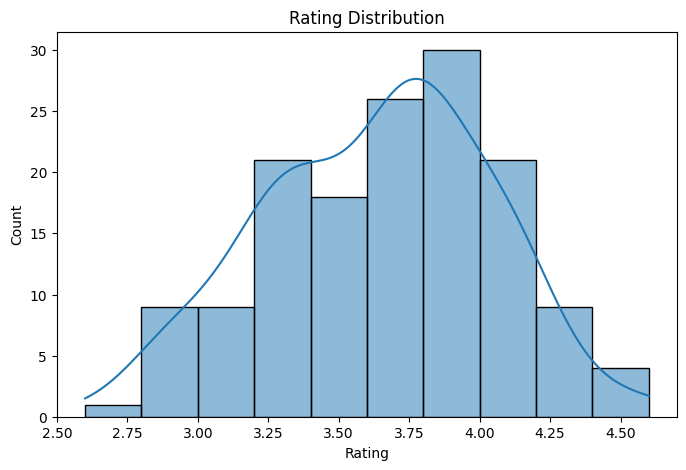

In [25]:
#Task 6: Rating Analysis
#Q1 Distribution of Ratings
plt.figure(figsize=(8,5))

sns.histplot(
    df['Rating'],
    bins=10,
    kde=True
)

plt.title("Rating Distribution")

plt.show()

In [26]:
#Q2 Calculate Skewness
print("Skewness =", df['Rating'].skew())
if df['Rating'].skew() > 0:
    print("Positively Skewed")
elif df['Rating'].skew() < 0:
    print("Negatively Skewed")
else:
    print("Symmetric Distribution")

Skewness = -0.15604931960897167
Negatively Skewed


In [27]:
#Q3 Detect Outliers Using IQR
Q1 = df['Rating'].quantile(0.25)

Q3 = df['Rating'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['Rating'] < lower_limit) |
    (df['Rating'] > upper_limit)
]

print("Number of Outliers =", len(outliers))

print(outliers)

Number of Outliers = 0
Empty DataFrame
Columns: [name, online_order, book_table, Rating, Votes, Cost, listed_in(type), City, Cuisine]
Index: []


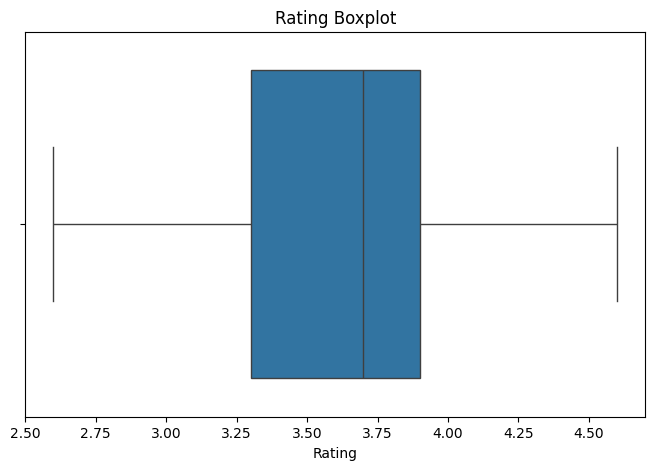

In [28]:
#Q4 Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Rating'])

plt.title("Rating Boxplot")

plt.show()

online_order
No     90
Yes    58
Name: count, dtype: int64
online_order
No     3.487778
Yes    3.858621
Name: Rating, dtype: float64


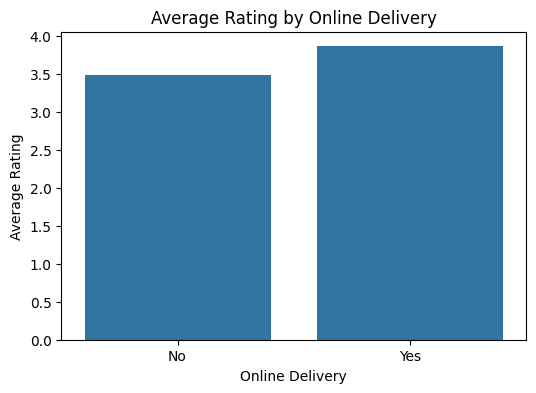

In [29]:
#Task 7: Online Delivery Analysis
#Q1 Restaurants Providing Online Delivery
delivery_count = df['online_order'].value_counts()

print(delivery_count)
#Q2 Compare Average Ratings
avg_rating = (
    df.groupby('online_order')['Rating']
    .mean()
)

print(avg_rating)
#Q3 Visualization
plt.figure(figsize=(6,4))

sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values
)

plt.title("Average Rating by Online Delivery")

plt.xlabel("Online Delivery")

plt.ylabel("Average Rating")

plt.show()

Average Cost = ₹ 418.24
                    name  Cost  Rating
97  Ayda Persian Kitchen   950     3.7
Correlation = 0.27521574616074335


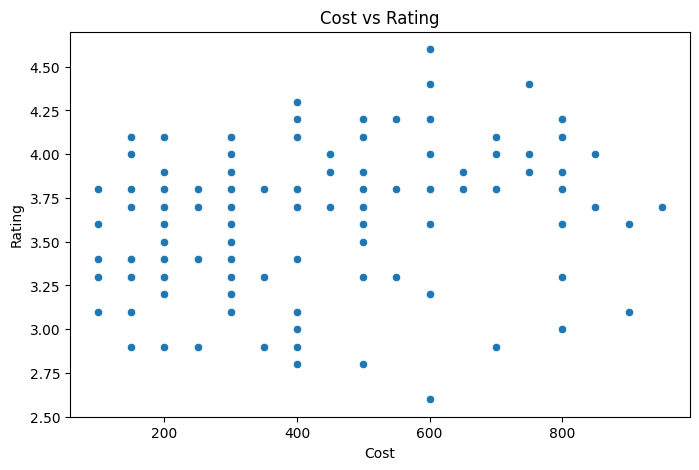

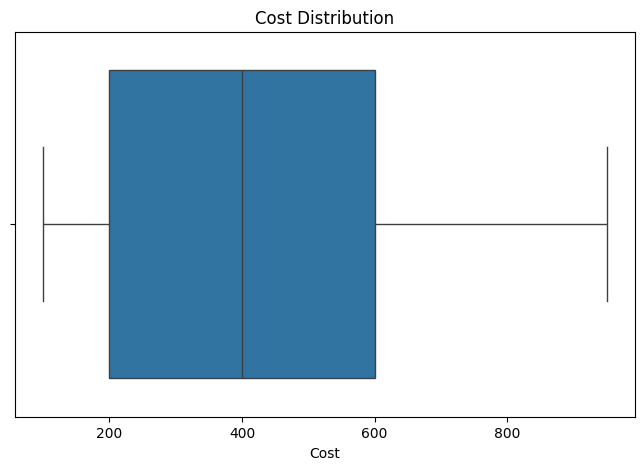

In [30]:
#Task 8: Cost Analysis
#Q1 Average Restaurant Cost
print("Average Cost = ₹", round(df['Cost'].mean(),2))
max_cost = df['Cost'].max()
#Q2 Most Expensive Restaurants
expensive_restaurants = df[
    df['Cost'] == max_cost
]

print(
    expensive_restaurants[
        ['name','Cost','Rating']
    ]
)
#Q3 Relationship Between Cost and Rating
correlation = df['Cost'].corr(df['Rating'])

print("Correlation =", correlation)
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Cost',
    y='Rating',
    data=df
)

plt.title("Cost vs Rating")

plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Cost'])

plt.title("Cost Distribution")

plt.show()

           Votes      Cost    Rating
Votes   1.000000  0.324372  0.489844
Cost    0.324372  1.000000  0.275216
Rating  0.489844  0.275216  1.000000


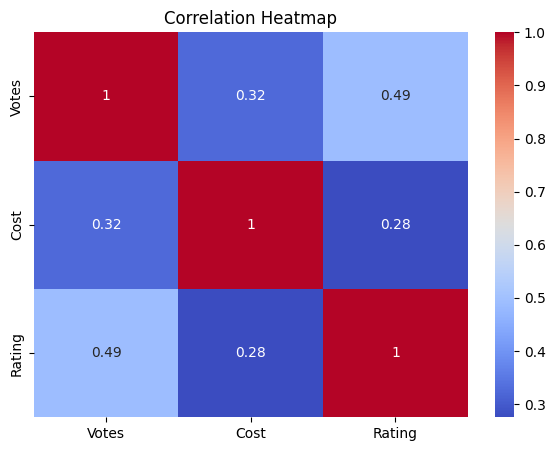

,Votes,Cost,Rating
Votes,1.000000,0.324372,0.489844
Cost,0.324372,1.000000,0.275216
Rating,0.489844,0.275216,1.000000


In [31]:
#Task 9: Correlation Analysis
#Q1 Correlation Matrix
corr_matrix = df[
    ['Votes','Cost','Rating']
].corr()

print(corr_matrix)
#Q2 Heatmap'
plt.figure(figsize=(7,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()
#Q3 Strongest Relationship
corr_matrix

Cost_Category
Budget      67
Moderate    54
Premium     27
Name: count, dtype: int64


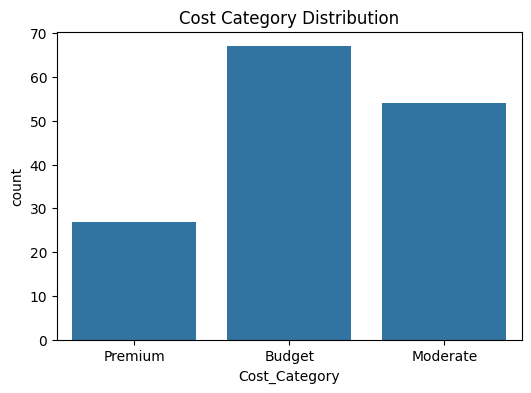

In [32]:
#Task 10: Feature Engineering
#Q1 Create Cost Category
def cost_category(cost):

    if cost <= 300:
        return "Budget"

    elif cost <= 600:
        return "Moderate"

    elif cost <= 1000:
        return "Premium"

    else:
        return "Luxury"

df['Cost_Category'] = df['Cost'].apply(
    cost_category
)

print(df['Cost_Category'].value_counts())
plt.figure(figsize=(6,4))

sns.countplot(
    x='Cost_Category',
    data=df
)

plt.title("Cost Category Distribution")

plt.show()

Rating_Category
Good         66
Average      46
Excellent    24
Poor         12
Name: count, dtype: int64


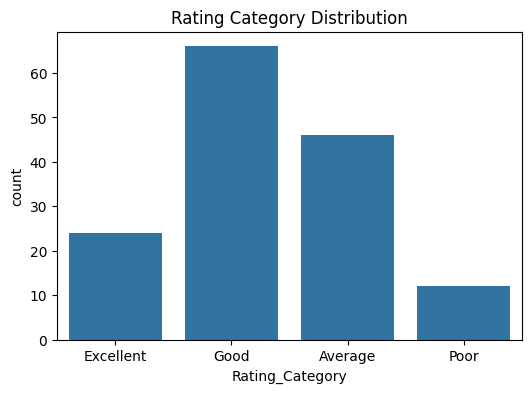

Rating_Category,Average,Excellent,Good,Poor
Cost_Category,,,,
Budget,33,6,24,4
Moderate,11,12,25,6
Premium,2,6,17,2


In [34]:
#Q2 Create Rating Category
def rating_category(rating):

    if rating <= 3:
        return "Poor"

    elif rating <= 3.5:
        return "Average"

    elif rating <= 4:
        return "Good"

    else:
        return "Excellent"

df['Rating_Category'] = df['Rating'].apply(
    rating_category
)

print(df['Rating_Category'].value_counts())
plt.figure(figsize=(6,4))

sns.countplot(
    x='Rating_Category',
    data=df
)

plt.title("Rating Category Distribution")

plt.show()
pd.crosstab(
    df['Cost_Category'],
    df['Rating_Category']
)

In [ ]:
#